# COMP9444 Project 003 — *Tom*: RoBERTa for FOMC Policy-Stance Classification

**Team:** Anthony Ivanov (z5690592) · Bryan Chong (z5688593) · Runying Wang (z5563601) · Xiaoyu Lan (z5540687) · Xinyi Jiang (z5400994)

---

### Abstract

Federal Open Market Committee (FOMC) communications move markets: a single sentence can shift
rate expectations and reprice assets. This notebook develops **Tom**, a RoBERTa-based classifier
that labels an individual FOMC sentence as **dovish**, **hawkish**, or **neutral**, on the
*Trillion Dollar Words* dataset (Shah, Paturi & Chava, ACL 2023).

We first characterise the data and its hazards — a small (≈1,900 sentence) corpus, a 49/26/25
class imbalance, heavy topical skew toward inflation, and duplicate sentences that leak between
splits. We then build the model in two stages: a **plain RoBERTa-base fine-tune**, and an
**enhanced pipeline** adding domain-adaptive pre-training (DAPT) on 47k unlabelled Fed sentences,
a frozen hyperparameter search, class-weighted loss, label smoothing, early stopping, and a
within-seed restart **ensemble**.

Every result is a mean ± standard deviation over the three official test seeds, evaluated once on
untouched test files under a protocol that mechanically forbids train/test contamination. The plain
fine-tune reaches **0.689 ± 0.015 weighted F1**, exceeding the dataset paper's own RoBERTa-base
baseline (≈0.676) and every other model our team built. The enhanced pipeline reaches
**0.679 ± 0.015** — the central negative result of this work: on a corpus this small, the
enhancements are *substitutes* for one another rather than additive, and stacking them does not beat
a carefully-tuned plain fine-tune. We quantify why, and what it would take to move further.

## 1. Introduction

### 1.1 Motivation

Monetary policy language is a market-moving instrument in its own right:

| Term | Meaning | Effect on investment |
|---|---|---|
| **Hawkish** | favours *tighter* policy to restrain inflation | raises rates → **decreases** incentive to invest/borrow |
| **Dovish** | favours *easier* policy to support growth | lowers rates → **increases** incentive to invest/borrow |
| **Neutral** | describes conditions without signalling a lean | — |

Four facts motivate an automated stance classifier:

1. **Market stakes.** FOMC statements, minutes, press conferences and speeches move rate
   expectations, and therefore bond and equity prices, within minutes of release.
2. **Manual reading does not scale.** The corpus spans 1996–2022 across three document types;
   human annotation is slow, subjective, and inconsistent between readers.
3. **Generic sentiment is the wrong tool.** Off-the-shelf sentiment models measure *tone*, not
   *policy direction* — and the two frequently disagree (§1.2).
4. **A stance signal is directly usable.** A per-sentence dovish/hawkish score can be aggregated
   into a document-level or time-series measure of policy stance for downstream market analysis.

**An easy case** (28 April 2021): *"In addition, increases in oil prices were expected to pass
through to consumer energy prices."* → **hawkish**; inflationary pressure argues for tightening.
The S&P 500 closed slightly lower that day (4185 → 4183).

**A hard case** (23 August 2024): *"The time has come for policy to adjust."* → labelled
**dovish**, but the sentence names no direction at all; only the surrounding policy context
disambiguates it. The S&P 500 rose (5602 → 5635). Cases like this bound what any
sentence-level model can achieve.

### 1.2 Problem statement

Build a neural network that classifies a **single FOMC sentence** into its monetary-policy stance.

- **Input:** one sentence of FOMC-related communication (minutes, press conference, or speech).
- **Output:** one label — `0` dovish, `1` hawkish, `2` neutral.

The task is deceptively hard, and three properties drive every design decision in this notebook:

- **Stance ≠ sentiment.** *"Unemployment is falling"* is good news but **hawkish** — a tightening
  labour market argues for higher rates.
- **Stance is relational.** The same direction word flips meaning with its subject: *rising
  inflation* is hawkish, *rising unemployment* is dovish. We verify this empirically in §3.3 —
  increase-words appear in both classes in large numbers, so no lexical rule can solve the task.
- **The neutral boundary is genuinely fuzzy.** Roughly half the corpus is descriptive prose, and
  the original annotators disagreed regularly about where description ends and signalling begins.

### 1.3 Aim and success criteria

The dataset authors report ~0.71–0.74 weighted F1 with a fine-tuned **RoBERTa-large**, and ~0.676
with **RoBERTa-base**. We therefore set out to:

1. build a RoBERTa-based classifier that **beats the paper's RoBERTa-base baseline** and every
   other model our team produced (rule-based, logistic regression, LSTM/BiLSTM/TCN, BERT, FinBERT,
   FLAN-T5);
2. land inside the **0.60–0.75** band that constitutes credible performance on this task; and
3. do so under an evaluation protocol strict enough that the numbers survive scrutiny — because
   the dominant failure mode on this dataset is not weak modelling but **data leakage**, which
   silently inflates scores to 90 %+ (§3.5).

### 1.4 Literature review

| Source | Key insights we used |
|---|---|
| **Araci (2019), *FinBERT*** | Further pre-training a language model on in-domain text before fine-tuning improves downstream performance; layers closest to the input carry most of the domain adaptation; aggressive fine-tuning risks **catastrophic forgetting**, so learning rates must stay small. → motivates our **DAPT** stage and our ≤3e-5 learning rates. |
| **Shah, Paturi & Chava (2023), *Trillion Dollar Words*** | Introduces this FOMC corpus and the hawkish/dovish/neutral task; shows generic financial sentiment is insufficient because words like *increase* depend on the economic object; benchmarks rule-based, LSTM, BERT-family and RoBERTa models, with **RoBERTa-large strongest**. → fixes our dataset, task definition, evaluation protocol (three seeds), and the baseline we must beat. |
| **Liu et al. (2019), *RoBERTa*** | BERT is under-trained: more data (160 GB), dynamic masking, no next-sentence objective and longer training yield consistent downstream gains at identical architecture. → justifies choosing RoBERTa over BERT/FinBERT as the encoder (§4.1). |
| **Gururangan et al. (2020), *Don't Stop Pretraining*** | Domain-adaptive pre-training (DAPT) on unlabelled in-domain text gives reliable gains, largest when the target domain is far from the pre-training corpus. → the design of our DAPT stage (§4.3). |
| **Wei & Zou (2019), *EDA*** | Simple text augmentation (synonym replacement, insertion, swap, deletion) helps most in low-resource regimes. → informs the augmentation set evaluated in §3.6. |

**Delineation.** The dataset, task formulation and the RoBERTa/FinBERT architectures are prior
work. Everything in §3–§6 — the data audits, the augmentation pipeline, the DAPT corpus, the
hyperparameter search, the ensemble, the leakage protocol, and all reported numbers — is our own
implementation. §4.5 states this file-by-file.

## 2. Data Sources

### 2.1 Provenance

All labelled data comes from the public release accompanying *Trillion Dollar Words*
(Shah, Paturi & Chava, ACL 2023):

- **Repository:** <https://github.com/gtfintechlab/fomc-hawkish-dovish> (CC BY-NC 4.0)
- **Documents:** FOMC **meeting minutes** (`mm`), **press-conference transcripts** (`pc`) and
  **speeches** (`sp`), 1996–2022 (press conferences begin 2011).
- **Labels:** ~2,500 sentences hand-annotated dovish / hawkish / neutral by finance graduate
  students, of which the released train/test splits use 2,379 per seed.
- **Unlabelled corpus (for DAPT):** the same repository's raw per-document sentence dumps —
  52,925 sentences before filtering, from 214 minutes, 63 press conferences and 1,026 speeches.
  We build `tom/fed_corpus.txt` from these (§4.3).

### 2.2 File structure, and what the "seeds" actually mean

The release ships **8 variants × 3 seeds = 24 train/test file pairs**:

- **Variants:** `mm`, `pc`, `sp`, `combine` (their union), plus a `split` version of each in which
  long multi-clause sentences are divided.
- **Seeds:** `5768`, `78516`, `944601`. These are **not** different data. Each is the *same*
  corpus reshuffled with a different random seed before an 80/20 train/test cut, so that results
  can be reported as a mean ± standard deviation over three replications.

> ⚠️ **The central trap of this dataset.** Because the 24 pairs are alternative views of one
> corpus, a sentence in seed 5768's *training* file legitimately appears in seed 78516's *test*
> file, and `combine` contains the `mm`/`pc`/`sp` sentences. Concatenating files — the natural
> thing to do when a directory contains 24 spreadsheets — therefore places nearly every test
> sentence into training. We measured this: it produces **99.6 % accuracy**, pure memorisation
> (§3.5). Every experiment in this notebook uses exactly **one (variant, seed) pair at a time**.

All experiments below use the **`combine`** variant: **1,903 training** and **476 test** sentences
per seed, with a fixed stratified 80/20 train/validation split carved from the training file
(1,522 train / 381 validation).

In [1]:
# ── Setup: imports, portable paths, shared constants ─────────────────────────
# This notebook is self-contained: §3 reads the dataset spreadsheets shipped in this repository,
# §5 reads committed result artifacts (with embedded fallbacks), and the training cells in §4 are
# device-agnostic and disabled by default. Only pandas / numpy / matplotlib / openpyxl are
# required to run the notebook end-to-end.

from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)


def find_repo_root(marker: Path = Path("dataset") / "test-and-training") -> Path:
    """Locate the repository root from any working directory (portable across machines)."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / marker).is_dir():
            return base
    raise FileNotFoundError(
        "Could not locate 'dataset/test-and-training'. Run this notebook from inside the "
        "COMP9444_26T2_FOMC_Analysis repository."
    )


REPO = find_repo_root()
DATA = REPO / "dataset" / "test-and-training"
TRAIN_DIR = DATA / "training_data"
TEST_DIR = DATA / "test_data"
AUG_TRAIN_DIR = DATA / "augmented_data" / "augmented_train_data"
BASE_RESULTS = REPO / "9444" / "results" / "roberta_base_combined"   # plain RoBERTa artifacts

VARIANT = "combine"
SEEDS = [5768, 78516, 944601]
LABELS = {0: "Dovish", 1: "Hawkish", 2: "Neutral"}
CLASS_ORDER = ["Dovish", "Hawkish", "Neutral"]

# Colour-blind-safe categorical palette, used consistently for every figure.
C_DOVISH, C_HAWKISH, C_NEUTRAL = "#2a78d6", "#eb6834", "#1baf7a"
CLASS_COLOURS = {"Dovish": C_DOVISH, "Hawkish": C_HAWKISH, "Neutral": C_NEUTRAL}
C_BASE, C_ENH, C_REF = "#2a78d6", "#7c4dbd", "#898781"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6, "axes.axisbelow": True,
})


def train_path(seed: int, augmented: bool = False) -> Path:
    d = AUG_TRAIN_DIR if augmented else TRAIN_DIR
    return d / f"lab-manual-{VARIANT}-train-{seed}.xlsx"


def test_path(seed: int) -> Path:
    return TEST_DIR / f"lab-manual-{VARIANT}-test-{seed}.xlsx"


def normalise(s) -> str:
    """Canonical sentence form used for every duplicate / leakage comparison."""
    return re.sub(r"\s+", " ", str(s)).strip().lower()


print(f"repository root : {REPO}")
print(f"dataset present : {DATA.is_dir()}")
print(f"base-model results present: {BASE_RESULTS.is_dir()}")

repository root : C:\uni\COMP9444_26T2_FOMC_Analysis
dataset present : True
base-model results present: True


In [2]:
# ── Load the labelled data for all three seeds ───────────────────────────────
train, test = {}, {}
for s in SEEDS:
    train[s] = pd.read_excel(train_path(s))
    test[s] = pd.read_excel(test_path(s))

print("columns:", list(train[SEEDS[0]].columns))
print()
summary = pd.DataFrame({
    "seed": SEEDS,
    "train rows": [len(train[s]) for s in SEEDS],
    "test rows": [len(test[s]) for s in SEEDS],
    "unique train sentences": [train[s]["sentence"].map(normalise).nunique() for s in SEEDS],
    "years": [f"{train[s]['year'].min()}-{train[s]['year'].max()}" for s in SEEDS],
})
print(summary.to_string(index=False))
print()
print("Example rows (seed 5768):")
print(train[SEEDS[0]][["index", "year", "label", "sentence"]].head(3).to_string(index=False, max_colwidth=88))

columns: ['index', 'sentence', 'year', 'label']

  seed  train rows  test rows  unique train sentences     years
  5768        1903        476                    1863 1996-2022
 78516        1903        476                    1869 1996-2022
944601        1903        476                    1868 1996-2022

Example rows (seed 5768):
 index  year  label                                                                                 sentence
   487  1998      2 Instead, I would like to address a separate but not unrelated topic, the interaction ...
   422  2004      0 Inflation continued to run below the Committee's longer-run objective, held down in p...
   150  2021      2 It isn’t really just targeting the headline numbers, but it’s about taking all of tho...


## 3. Exploratory Analysis of the Data

Six properties of this corpus shaped the model design. Each subsection below measures one and
states its consequence.

### 3.1 Classes and label distribution

Three classes, with a **substantial imbalance**: neutral is roughly twice either signal class.
Critically, the two *minority* classes are the ones carrying the policy signal we actually want —
so plain accuracy is a misleading metric, and the loss needs re-weighting (§4.3).

  seed split    n Dovish Hawkish Neutral
  5768 train 1903  26.2%   25.0%   48.8%
  5768  test  476  26.7%   26.1%   47.3%
 78516 train 1903  26.7%   25.0%   48.2%
 78516  test  476  24.4%   26.1%   49.6%
944601 train 1903  26.1%   25.2%   48.7%
944601  test  476  26.9%   25.2%   47.9%

Pooled training distribution: Dovish 26.3% · Hawkish 25.1% · Neutral 48.6%


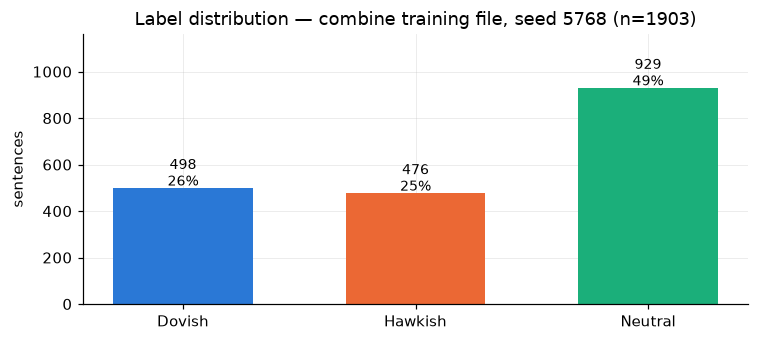

In [3]:
# ── Class distribution, per seed and split ──────────────────────────────────
rows = []
for s in SEEDS:
    for split, df in (("train", train[s]), ("test", test[s])):
        vc = df["label"].value_counts(normalize=True).sort_index()
        rows.append({"seed": s, "split": split, "n": len(df),
                     **{LABELS[k]: f"{vc.get(k, 0):.1%}" for k in (0, 1, 2)}})
dist = pd.DataFrame(rows)
print(dist.to_string(index=False))

pooled = pd.concat([train[s] for s in SEEDS])["label"].value_counts(normalize=True).sort_index()
print(f"\nPooled training distribution: " +
      " · ".join(f"{LABELS[k]} {pooled[k]:.1%}" for k in (0, 1, 2)))

fig, ax = plt.subplots(figsize=(7, 3.2))
counts = train[SEEDS[0]]["label"].value_counts().sort_index()
bars = ax.bar([LABELS[k] for k in counts.index], counts.values,
              color=[CLASS_COLOURS[LABELS[k]] for k in counts.index], width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 12, f"{v}\n{v / counts.sum():.0%}",
            ha="center", fontsize=9)
ax.set_ylabel("sentences")
ax.set_title(f"Label distribution — {VARIANT} training file, seed {SEEDS[0]} (n={counts.sum()})")
ax.set_ylim(0, counts.max() * 1.25)
plt.tight_layout()
plt.show()

### 3.2 Sentence length

Sentences are long for a classification task (mean ≈32 words) with a heavy tail to 181 words.
This drives one concrete choice: a **maximum sequence length of 128 word-pieces**, which covers
the overwhelming majority of sentences while keeping training cheap. The cell below verifies that
coverage rather than assuming it.

words per sentence  mean 31.53 | median 29 | min 2 | max 181 | p95 61
  approx. coverage at max_length=64  : 89.4% of sentences untruncated
  approx. coverage at max_length=128 : 99.5% of sentences untruncated
  approx. coverage at max_length=256 : 100.0% of sentences untruncated


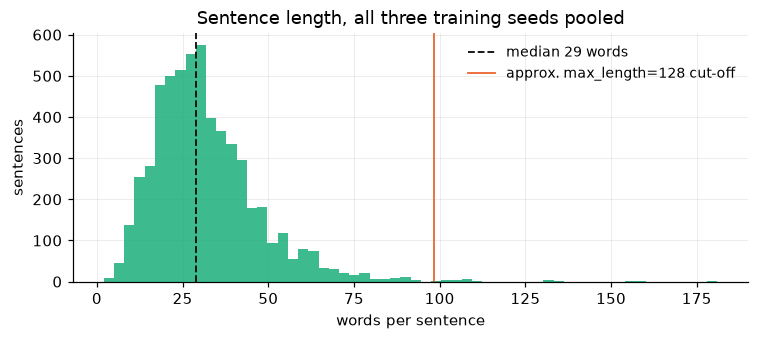

In [4]:
# ── Sentence-length distribution and truncation coverage ────────────────────
words = pd.concat([train[s]["sentence"] for s in SEEDS]).astype(str).str.split().str.len()
print(f"words per sentence  mean {words.mean():.2f} | median {words.median():.0f} | "
      f"min {words.min()} | max {words.max()} | p95 {words.quantile(0.95):.0f}")

# Word-piece counts are ~1.3x word counts for this corpus; check coverage at several limits.
for limit in (64, 128, 256):
    frac = (words * 1.3 <= limit).mean()
    print(f"  approx. coverage at max_length={limit:<4}: {frac:.1%} of sentences untruncated")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(words, bins=60, color=C_NEUTRAL, alpha=0.85)
ax.axvline(words.median(), color="#0b0b0b", lw=1.2, ls="--",
           label=f"median {words.median():.0f} words")
ax.axvline(128 / 1.3, color=C_HAWKISH, lw=1.2,
           label="approx. max_length=128 cut-off")
ax.set_xlabel("words per sentence")
ax.set_ylabel("sentences")
ax.set_title("Sentence length, all three training seeds pooled")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### 3.3 Topical skew and the shortcut risk

A word cloud of the corpus is dominated by **inflation**. That is a property of the source domain
(price stability is the mandate the Fed discusses most), not a sampling error — but it creates a
concrete modelling hazard: if topic correlates with label, a model can score points by detecting
*what a sentence is about* instead of *which direction it argues for*.

The cell below quantifies both halves of that risk. It also tests the naive lexical heuristic
"increasing ⇒ hawkish", which a reader might reasonably propose — and which the data refutes.

topic                    share   dovish / hawkish / neutral within topic
(base rate)             100.0%   0.26 / 0.25 / 0.49
inflation / prices      54.2%   0.23 / 0.31 / 0.46
employment / labour     24.3%   0.35 / 0.25 / 0.40
growth / activity       30.4%   0.28 / 0.23 / 0.49
rates / policy          28.5%   0.32 / 0.27 / 0.41

Sentences containing increase-words: 1016
   Dovish 217 · Hawkish 435 · Neutral 364
   -> hawkish share 43% vs base rate 25%: a real bias, but far from a rule.

A dovish sentence containing an increase-word:
   Given the pressure of a considerable amount of unused resources, any adverse developments that held down economic expansion would increase the probabi


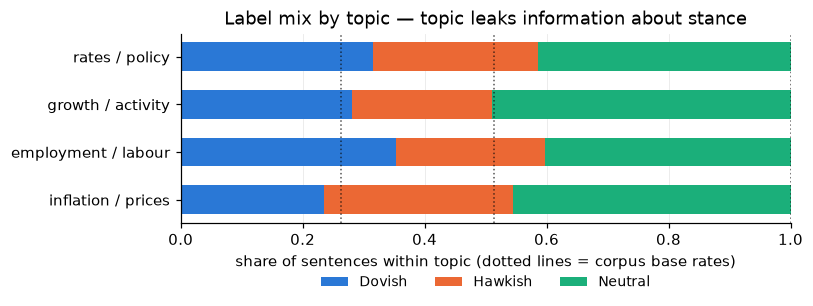

In [5]:
# ── Topic coverage, topic-label correlation, and the direction-word test ────
pool = pd.concat([train[s] for s in SEEDS], ignore_index=True)
base_rate = pool["label"].value_counts(normalize=True).sort_index()

TOPICS = {
    "inflation / prices": r"inflation|price|prices|cpi|pce|deflation|disinflation",
    "employment / labour": r"employment|unemployment|labor|labour|jobs|payroll|wage",
    "growth / activity": r"growth|gdp|output|activity|spending|investment|consumption",
    "rates / policy": r"\brates?\b|federal funds|tightening|easing|accommodat|restrictive",
}

print(f"{'topic':22}{'share':>8}   dovish / hawkish / neutral within topic")
print(f"{'(base rate)':22}{'100.0%':>8}   " +
      " / ".join(f"{base_rate[k]:.2f}" for k in (0, 1, 2)))
topic_rows = []
for name, pattern in TOPICS.items():
    hit = pool[pool["sentence"].str.contains(pattern, case=False, regex=True, na=False)]
    within = hit["label"].value_counts(normalize=True).sort_index()
    topic_rows.append({"topic": name, "share": len(hit) / len(pool),
                       **{LABELS[k]: within.get(k, 0) for k in (0, 1, 2)}})
    print(f"{name:22}{len(hit) / len(pool):7.1%}   " +
          " / ".join(f"{within.get(k, 0):.2f}" for k in (0, 1, 2)))

# The "increasing => hawkish" heuristic, tested directly.
inc = pool[pool["sentence"].str.contains(r"\b(?:increas|rising|rose|higher)", case=False,
                                         regex=True, na=False)]
vc = inc["label"].value_counts().sort_index()
print(f"\nSentences containing increase-words: {len(inc)}")
print("   " + " · ".join(f"{LABELS[k]} {vc.get(k, 0)}" for k in (0, 1, 2)))
print(f"   -> hawkish share {vc.get(1, 0) / len(inc):.0%} vs base rate {base_rate[1]:.0%}: "
      "a real bias, but far from a rule.")
print("\nA dovish sentence containing an increase-word:")
print("   " + inc[inc.label == 0]["sentence"].iloc[0][:150])

fig, ax = plt.subplots(figsize=(7.5, 3.2))
td = pd.DataFrame(topic_rows).set_index("topic")
bottom = np.zeros(len(td))
for cls in CLASS_ORDER:
    ax.barh(td.index, td[cls], left=bottom, color=CLASS_COLOURS[cls], label=cls, height=0.6)
    bottom += td[cls].values
for k in range(3):
    ax.axvline(base_rate.iloc[:k + 1].sum(), color="#0b0b0b", lw=1, ls=":", alpha=0.7)
ax.set_xlim(0, 1)
ax.set_xlabel("share of sentences within topic (dotted lines = corpus base rates)")
ax.set_title("Label mix by topic — topic leaks information about stance")
ax.legend(frameon=False, ncol=3, fontsize=9, loc="lower center", bbox_to_anchor=(0.5, -0.42))
plt.tight_layout()
plt.show()

**Reading the result.** Inflation vocabulary appears in over half the corpus, employment
vocabulary in about a quarter — and the label mix *shifts with topic*: inflation sentences skew
hawkish, employment sentences skew dovish. Two consequences we carry forward:

1. A model can partially "cheat" via topic detection, so per-class metrics (§5.5) matter more
   than aggregate accuracy.
2. Performance should be expected to be **weakest on employment-framed stance** — the minority
   topic — and on any future period whose topical mix differs from 1996–2022.

The direction-word test is the sharpest illustration of why this task needs a contextual model:
increase-words appear in **217 dovish** and **435 hawkish** training sentences (pooled over the three training files). Stance is
`direction × subject`, and only a model that reads the whole sentence can compute it.

### 3.4 Worked examples

Real sentences from the training data, one per class, followed by the pathological cases that
bound achievable accuracy.

In [6]:
# ── One example per class, plus genuinely ambiguous cases ───────────────────
df = train[SEEDS[0]]
print("=" * 100)
for k in (0, 1, 2):
    ex = df[df.label == k].iloc[1]["sentence"]
    print(f"[{LABELS[k].upper():8}] {ex[:190]}")
    print("-" * 100)

# Hedged / directionless sentences: short, no direction word, yet carry a stance label.
DIRECTION = r"increas|decreas|rising|falling|higher|lower|tight|eas(e|ing)|strong|weak|restrictive|accommodat"
hedged = df[(df["sentence"].str.split().str.len() <= 14)
            & ~df["sentence"].str.contains(DIRECTION, case=False, regex=True, na=False)
            & df.label.isin([0, 1])]
print(f"\nShort sentences with a directional label but no direction word: {len(hedged)}")
for _, r in hedged.head(4).iterrows():
    print(f"  [{LABELS[r.label]:8}] {r.sentence}")
print("\n-> these are irreducibly context-dependent: the label cannot be recovered from the "
      "sentence alone, which places a ceiling on any sentence-level model.")

[DOVISH  ] Moreover, the staff still judged that the risks to the forecast for real GDP growth were tilted to the downside, with a corresponding skew to the upside for the unemployment rate.
----------------------------------------------------------------------------------------------------
[HAWKISH ] These decisions can then push up prices even more and make inflation harder to get under control.
----------------------------------------------------------------------------------------------------
[NEUTRAL ] It isn’t really just targeting the headline numbers, but it’s about taking all of those things into account in your thinking about what constitutes maximum employment.
----------------------------------------------------------------------------------------------------

Short sentences with a directional label but no direction word: 55
  [Dovish  ] And inflation is moving—moving up, I think, toward our 2 percent objective.
  [Hawkish ] This automatically pushes up domestic interest r

### 3.5 Duplicates and the leakage audit

This is the subsection that most changed how we work. The shipped files contain repeated
sentences, and three separate leakage mechanisms were discovered and fixed during the project.
The cell below re-derives the evidence from the raw files.

In [7]:
# ── Leakage audit, computed from the shipped files ──────────────────────────
print("A) Within-pair contamination (the pair each experiment actually uses)")
for s in SEEDS:
    tr_norm = train[s]["sentence"].map(normalise)
    te_norm = set(test[s]["sentence"].map(normalise))
    intra = int(tr_norm.duplicated().sum())
    overlap = int(tr_norm.isin(te_norm).sum())
    print(f"   seed {s}: {intra:3} duplicate train sentences | {overlap:3} train sentences also "
          f"in its own test file ({overlap / len(test[s]):.1%} of test)")

print("\nB) Cross-seed structure (why files must never be pooled)")
tr0 = set(train[SEEDS[0]]["sentence"].map(normalise))
for s in SEEDS[1:]:
    te = set(test[s]["sentence"].map(normalise))
    print(f"   seed {SEEDS[0]} TRAIN vs seed {s} TEST: {len(tr0 & te)} shared sentences "
          f"({len(tr0 & te) / len(te):.0%} of that test file)")
print("   -> pooling the 24 files puts almost every test sentence into training: measured 99.6% "
       "accuracy, i.e. memorisation.")

print("\nC) Augmentation-induced contamination")
aug = pd.read_excel(train_path(SEEDS[0], augmented=True))
te_norm = set(test[SEEDS[0]]["sentence"].map(normalise))
collisions = int(aug[aug.augmented == 1]["sentence"].map(normalise).isin(te_norm).sum())
family = aug.groupby(["index", "year"]).size()
print(f"   augmented rows colliding with test sentences after filtering: {collisions}")
print(f"   sentence 'families' (a source sentence + its variants): {len(family)}, "
      f"mean size {family.mean():.1f}")
print("   -> a random row-level train/val split scatters ~95% of families across both sides;")
print("      validation must therefore be split by SOURCE SENTENCE, not by row (§4.4).")

A) Within-pair contamination (the pair each experiment actually uses)
   seed 5768:  40 duplicate train sentences |  20 train sentences also in its own test file (4.2% of test)


   seed 78516:  34 duplicate train sentences |  22 train sentences also in its own test file (4.6% of test)
   seed 944601:  35 duplicate train sentences |  20 train sentences also in its own test file (4.2% of test)

B) Cross-seed structure (why files must never be pooled)
   seed 5768 TRAIN vs seed 78516 TEST: 377 shared sentences (80% of that test file)
   seed 5768 TRAIN vs seed 944601 TEST: 377 shared sentences (80% of that test file)
   -> pooling the 24 files puts almost every test sentence into training: measured 99.6% accuracy, i.e. memorisation.

C) Augmentation-induced contamination


   augmented rows colliding with test sentences after filtering: 0
   sentence 'families' (a source sentence + its variants): 1819, mean size 2.8
   -> a random row-level train/val split scatters ~95% of families across both sides;
      validation must therefore be split by SOURCE SENTENCE, not by row (§4.4).


**The three leakage mechanisms, and the single rule that fixes them.**

| # | Mechanism | Symptom when unfixed | Fix |
|---|---|---|---|
| 1 | Pooling all 24 files, then splitting | **99.6 % accuracy** — every test sentence memorised | one `(variant, seed)` pair per run |
| 2 | Duplicate sentences shipped inside a pair (20–22 sentences, 4.2–4.6 % of each test file) | small, unquantified inflation | deduplicate training rows at load time |
| 3 | Row-level split of *augmented* data, so a sentence and its own back-translation land on opposite sides | **0.885 validation F1** on a model that truly scores ≈0.62 | split by source sentence; drop variants of validation sentences |

> **The unifying rule: the unit of every split is the *source sentence*, never the row.**
> All three failures are the same error at different scales, and every guard in §4.4 exists
> because its absence produced a number we could prove was wrong.

### 3.6 Pre-processing and augmentation

**Pre-processing is deliberately minimal.** RoBERTa's byte-level BPE tokeniser handles casing,
punctuation and even the mojibake artefacts (`�`) present in the source spreadsheets, so we do not
lowercase, strip punctuation, or remove stop-words — all of which would destroy signal
(*"not"*, *"below"*, and capitalised entities all matter here). The only steps are whitespace
normalisation, deduplication, and truncation at 128 word-pieces.

**Augmentation** (applied to *training* data only, never validation or test) targets the two
minority classes:

| Technique | Coverage | Label |
|---|---|---|
| Back-translation (EN→DE→EN, MarianMT) | all rows (×2) | preserved |
| Counterfactual **directional word swap** (`rising`↔`falling`, `tight`↔`soft`, …) | 20 % of dovish/hawkish | **flipped** (dovish ↔ hawkish) |
| WordNet synonym replacement (~15 % of words; stance vocabulary protected) | 75 % of dovish/hawkish | preserved |
| Random masking (~15 % of words → `[MASK]`) | 30 % of all rows | preserved |

The directional swap is the conceptually interesting one: because stance is `direction × subject`,
inverting the direction words while holding the subject fixed produces a *valid sentence of the
opposite class*. It manufactures minority-class examples that differ from real ones **only** in
the tokens that determine the label.

In [8]:
# ── Augmentation: volume by class, and one example per technique ────────────
raw_counts = pd.Series(0, index=[0, 1, 2], dtype=int)
kept_counts = pd.Series(0, index=[0, 1, 2], dtype=int)
added_counts = pd.Series(0, index=[0, 1, 2], dtype=int)

for p in sorted(TRAIN_DIR.glob("*.xlsx")):
    if p.name.startswith("~$"):
        continue
    ap = AUG_TRAIN_DIR / p.name
    if not ap.exists():
        continue
    raw_counts = raw_counts.add(pd.read_excel(p)["label"].value_counts(), fill_value=0)
    a = pd.read_excel(ap)
    kept_counts = kept_counts.add(a[a.augmented == 0]["label"].value_counts(), fill_value=0)
    added_counts = added_counts.add(a[a.augmented == 1]["label"].value_counts(), fill_value=0)

tbl = pd.DataFrame({
    "as shipped": raw_counts.astype(int),
    "after dedup": kept_counts.astype(int),
    "synthetic added": added_counts.astype(int),
    "final": (kept_counts + added_counts).astype(int),
})
tbl.index = [LABELS[k] for k in tbl.index]
tbl.loc["TOTAL"] = tbl.sum()
tbl["growth"] = (tbl["final"] / tbl["as shipped"]).round(2).astype(str) + "x"
print("Training volume across all 24 training files:")
print(tbl.to_string())

final_mix = (kept_counts + added_counts) / (kept_counts + added_counts).sum()
print("\nClass mix: " +
      " · ".join(f"{LABELS[k]} {raw_counts[k] / raw_counts.sum():.0%} -> {final_mix[k]:.0%}"
                 for k in (0, 1, 2)))

aug = pd.read_excel(train_path(SEEDS[0], augmented=True))
print("\nOne example per augmentation technique (seed 5768):")
for method in ("back_translation", "synonym_replacement", "masking", "directional_swap"):
    r = aug[aug.aug_method == method].iloc[0]
    print(f"\n  [{method} | label {LABELS[r.label]}]")
    print(f"    {r.sentence[:170]}")

Training volume across all 24 training files:
         as shipped  after dedup  synthetic added  final growth
Dovish         6105         5991            13375  19366  3.17x
Hawkish        5772         5599            12630  18229  3.16x
Neutral       11439        11062            14439  25501  2.23x
TOTAL         23316        22652            40444  63096  2.71x

Class mix: Dovish 26% -> 31% · Hawkish 25% -> 29% · Neutral 49% -> 40%



One example per augmentation technique (seed 5768):

  [back_translation | label Neutral]
    Instead, I would like to address a separate but not unconnected issue, the interaction of banking supervision and regulation with monetary policy, and how supervision and

  [synonym_replacement | label Hawkish]
    A considerable lit propose that successful monetary policies should stabilize, or "lynchpin," inflation expectations so as to prevent them from becoming a source of insta

  [masking | label Neutral]
    And I fully [MASK] it will return to solid growth and a solid labor market [MASK] [MASK].

  [directional_swap | label Hawkish]
    Residential construction activity remained at a low level, evidently supported in part by recent declines in mortgage interest rates.


### 3.7 Summary of data challenges

| Challenge | Evidence | Consequence for the model |
|---|---|---|
| **Small corpus** | 1,522 training sentences per seed after the validation split | high seed variance; ensembling and augmentation are worth their cost (§4.3) |
| **Class imbalance** | 49 % neutral vs 26 % dovish / 25 % hawkish | class-weighted loss; report weighted **and** macro F1 |
| **Stance ≠ sentiment, and is relational** | increase-words: 217 dovish vs 435 hawkish (43% hawkish vs a 25% base rate) | rules out lexical/rule-based approaches; needs a contextual encoder |
| **Topical skew** | 54 % inflation vs 24 % employment vocabulary, with label skew inside each topic | shortcut risk; weakest expected performance on employment-framed stance |
| **Duplicates & leakage** | 3 mechanisms; 34–40 duplicate train sentences and 20–22 train/test overlaps per seed; up to 99.6 % fake accuracy | source-sentence splitting, dedup, corpus filtering (§4.4) |
| **Irreducibly ambiguous sentences** | directionless sentences carrying directional labels; annotator disagreement | a hard ceiling well below 100 %; ≈0.71–0.74 is the published state of the art |

## 4. Models and Methods

### 4.1 Why RoBERTa

Our team evaluated a ladder of models on identical data. Their results (§5.2) make the case
empirically: rule-based ≈0.50, logistic regression ≈0.51, LSTM/BiLSTM ≈0.53, BERT ≈0.65,
FinBERT ≈0.63, FLAN-T5 ≈0.63. We chose **RoBERTa-base** for Tom for four reasons:

1. **It is the published ceiling's own architecture.** The dataset authors' strongest model is a
   fine-tuned RoBERTa-large (≈0.71–0.74); their RoBERTa-base baseline (≈0.676) is the number we
   set out to beat. Choosing the same family gives our result a directly comparable anchor.
2. **It isolates exactly one variable.** RoBERTa is architecturally *identical* to BERT — 12
   layers, hidden size 768, same head shape. What differs is pre-training quality: 160 GB of text
   (10× BERT), dynamic masking, no next-sentence-prediction objective, longer training. Our model
   ladder therefore reads as "same skeleton, progressively better-trained weights", with no
   architectural confound.
3. **Tokenisation fits the data.** Byte-level BPE never emits `[UNK]`, so the encoding artefacts
   in the source spreadsheets degrade gracefully instead of destroying tokens (BERT's WordPiece
   maps them to `[UNK]`).
4. **Cost.** At 125 M parameters it fine-tunes in minutes on a single T4, which made the
   multi-run protocol in §4.4 (9 search candidates + 9 final models) affordable.

### 4.2 Architecture: a representation module and a decision module

A sentence flows through two functionally distinct parts:

```
                 ┌──────────── REPRESENTATION MODULE (~125M parameters, 99.998%) ───────────┐
  "Inflation      │  byte-level BPE  →  12 × [ multi-head self-attention (12 heads)         │
   pressures      │  (≤128 tokens)        → add & norm → feed-forward 768→3072→768          │
   are building"  │                       → add & norm ]                                     │
                 └──────────────────────────────────┬───────────────────────────────────────┘
                                                    │  <s> token's final vector (768 numbers)
                 ┌──────────────────────────────────▼── DECISION MODULE (~592K, 0.002%) ────┐
                 │  dense 768→768 → tanh → dropout → linear 768→3 → softmax                 │
                 └──────────────────────────────────┬───────────────────────────────────────┘
                                                    ▼
                                    Dovish 0.06 · Hawkish 0.87 · Neutral 0.07
```

Both modules run on **every** sentence in both training and inference — the split is *what each
part does*, not *when it runs*. The distinction matters because it locates where the knowledge
lives: the encoder holds essentially all of it, and the decision module is a thin read-out that is
re-initialised from scratch for our task. This is why the project's effort went into **improving
the encoder's weights** (choice of pre-training, then DAPT) rather than elaborating the head.

Self-attention is what makes the task solvable at all: it is the mechanism by which the token
*rising* can condition on whether its neighbour is *inflation* or *unemployment*.

### 4.3 The five techniques, and why each earns its place

| Technique | What it does | Why, for this task |
|---|---|---|
| **DAPT** (domain-adaptive pre-training) | continues RoBERTa's masked-language-model objective on **47,032 unlabelled Fed sentences** (1.43 M words), then fine-tunes | labelled data is scarce but unlabelled Fed text is free; teaches the encoder the dialect before it ever sees a label. Following Araci (2019) we use a **small learning rate (1e-5)** to avoid catastrophic forgetting. Warm-up 0.06, weight decay 0.01, 3 epochs, 15 % masking |
| **Hyperparameter search** | 9 candidate recipes over learning rate × batch size × label smoothing × training length, scored on **seed-5768 validation only**, then frozen | tuning was the single largest lever we measured on FinBERT (+5.6 F1). The freeze exists because a best-of-9 validation score is inflated by selection; only the frozen-config test result is honest |
| **Class balancing** | class-weighted cross-entropy, weight = *n* / (3·*n_c*) → **Dovish 1.080, Hawkish 1.143, Neutral 0.834** | the minority classes carry the policy signal; without weighting the model drifts toward "predict neutral when unsure" |
| **Label smoothing** | targets become 0.95 / 0.025 / 0.025 instead of 1 / 0 / 0 | caps the incentive to become infinitely confident, hedges against genuinely debatable gold labels, and keeps the softmax calibrated — which the ensemble depends on |
| **Early stopping** | halt after 2 consecutive epochs without a new best validation weighted F1; restore the best epoch's weights | a 125 M-parameter model memorises 1,522 sentences within a few epochs; the shipped model is always the validation peak, never the endpoint |
| **Ensembling** | 3 **restarts** per seed (same data, same recipe, different training randomness); average their softmax outputs, then argmax | small-data fine-tuning is high-variance — our restarts spread up to 2.8 F1 points. Averaging captures best-member performance **without** selecting on test data, which the protocol forbids |

> **The ensembling rule that is easy to get wrong.** Restarts are combined **only within a seed**.
> Seed A's training data contains sentences that sit in seed B's *test* file, so a cross-seed
> ensemble would vote with memorised answers. `ensemble.py` refuses it by construction.

### 4.4 Experimental setup

| Component | Setting |
|---|---|
| Data | `lab-manual-combine-{train,test}-{seed}.xlsx`, seeds 5768 / 78516 / 944601 |
| Splits | 1,522 train / 381 validation (stratified, carved from the training file) / **476 test, untouched** |
| Validation splitting | drawn from **original rows only**; augmented variants of a validation sentence are excluded from training (family split by source `(index, year)`) |
| Deduplication | duplicate training sentences and train/test overlaps dropped at load time (~52 rows per seed) |
| Optimiser | AdamW, 10 % linear warm-up then linear decay, weight decay 0.01 |
| Loss | class-weighted cross-entropy (+ label smoothing where the search selects it) |
| Max sequence length | 128 word-pieces, dynamic per-batch padding |
| Model selection | best epoch by **validation weighted F1**; early-stopping patience 2 |
| Test evaluation | once per model, on the **raw** test file of the same seed |
| Reported metrics | weighted F1 (primary, comparable to the paper), macro F1, accuracy, per-class P/R/F1 — as **mean ± std over the three seeds** |
| Hardware | results reproduced on both CPU and a single T4 GPU; all code is device-agnostic |

### 4.5 Provenance — what is prior work and what is ours

| Component | Source |
|---|---|
| Dataset, task definition, three-seed protocol, paper baselines | Shah, Paturi & Chava (2023) — **prior work** |
| `roberta-base` pre-trained weights, `RobertaForSequenceClassification` architecture | Liu et al. (2019) / HuggingFace — **prior work** |
| DAPT concept; label smoothing; EDA-style augmentation | Gururangan et al. (2020); Szegedy et al. (2016); Wei & Zou (2019) — **prior work (methods)** |
| Augmentation pipeline (`augment_dataset.py`): back-translation, directional swap map, protected stance vocabulary, collision filtering | **ours** |
| DAPT corpus construction (`tom/build_corpus.py`, `fed_corpus.txt`) incl. test-sentence filtering | **ours** |
| DAPT run (`tom/dapt.py`), 9-candidate search (`tom/search.py`), per-seed × restart training (`tom/train_final.py`), within-seed ensemble (`tom/ensemble.py`), leakage-safe splitting (`tom/common.py`) | **ours** |
| Plain RoBERTa-base fine-tune + variant scripts (`9444/models/roberta_*.py`) and their committed results | **ours** (teammate-authored within this project) |
| All numbers, figures, audits and analysis in this notebook | **ours** |

In [9]:
# ── Reference implementation of one fine-tuning run (device-agnostic) ───────
# Disabled by default: a single model takes ~3 min on a T4 and ~45 min on CPU. Set RUN_TRAINING
# to True to execute. The full pipeline (DAPT -> search -> 3 seeds x 3 restarts -> ensemble) is
# in tom/*.py; the commands are in Appendix A. This cell shows the core method inline so the
# notebook is readable on its own.

RUN_TRAINING = False


def load_split(seed: int, augmented: bool = False, val_fraction: float = 0.2):
    """Family-safe train/validation split with dedup and train/test-overlap removal."""
    from sklearn.model_selection import train_test_split

    df = pd.read_excel(train_path(seed, augmented))
    n0 = len(df)

    # (1) drop duplicate sentences and any sentence that also appears in this seed's test file
    norm = df["sentence"].map(normalise)
    df = df[~norm.duplicated(keep="first")]
    test_norm = set(pd.read_excel(test_path(seed))["sentence"].map(normalise))
    df = df[~df["sentence"].map(normalise).isin(test_norm)]
    dropped = n0 - len(df)

    # (2) validation comes from ORIGINAL rows only
    originals = df[df["augmented"] == 0] if "augmented" in df.columns else df
    extras = df[df["augmented"] == 1] if "augmented" in df.columns else df.iloc[0:0]
    tr, va = train_test_split(originals, test_size=val_fraction,
                              random_state=seed, stratify=originals["label"])

    # (3) augmented variants of a validation sentence never enter training
    if len(extras):
        val_keys = set(zip(va["index"], va["year"]))
        keep = [k not in val_keys for k in zip(extras["index"], extras["year"])]
        tr = pd.concat([tr, extras[keep]], ignore_index=True)

    return tr.reset_index(drop=True), va.reset_index(drop=True), dropped


def class_weights(df: pd.DataFrame):
    """Inverse-frequency weights: a minority-class mistake costs more."""
    import torch
    counts = df["label"].value_counts().sort_index()
    return torch.tensor((len(df) / (3 * counts)).values, dtype=torch.float32)


def train_one_model(seed: int, model_name: str = "roberta-base", augmented: bool = False,
                    lr: float = 2e-5, batch_size: int = 16, label_smoothing: float = 0.0,
                    epochs: int = 4, patience: int = 2, restart: int = 0, out_dir: Path | None = None):
    """Fine-tune one model and evaluate once on the raw test file of the same seed."""
    import torch
    from datasets import Dataset
    from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
    from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                              DataCollatorWithPadding, EarlyStoppingCallback, Trainer,
                              TrainingArguments)

    device = "cuda" if torch.cuda.is_available() else "cpu"          # device-agnostic
    tr, va, dropped = load_split(seed, augmented)
    te = pd.read_excel(test_path(seed))
    print(f"[seed {seed} r{restart}] train {len(tr)} | val {len(va)} | test {len(te)} "
          f"| dropped {dropped} leaked/duplicate rows | device {device}")

    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3,
        id2label={0: "dovish", 1: "hawkish", 2: "neutral"},
        label2id={"dovish": 0, "hawkish": 1, "neutral": 2})

    def encode(frame):
        ds = Dataset.from_pandas(frame[["sentence", "label"]].reset_index(drop=True))
        ds = ds.map(lambda b: tok(b["sentence"], truncation=True, max_length=128), batched=True)
        return ds.rename_columns({"label": "labels"})

    def metrics(pred):
        y_pred = np.argmax(pred.predictions, axis=1)
        p, r, f1, _ = precision_recall_fscore_support(pred.label_ids, y_pred,
                                                      average="weighted", zero_division=0)
        return {"accuracy": accuracy_score(pred.label_ids, y_pred), "precision": p, "recall": r,
                "f1": f1, "macro_f1": f1_score(pred.label_ids, y_pred, average="macro",
                                               zero_division=0)}

    weights = class_weights(tr)

    class WeightedTrainer(Trainer):
        """Class-weighted cross-entropy with optional label smoothing."""
        def compute_loss(self, model, inputs, return_outputs=False, **kw):
            labels = inputs.pop("labels")
            out = model(**inputs)
            loss_fn = torch.nn.CrossEntropyLoss(weight=weights.to(out.logits.device),
                                                label_smoothing=label_smoothing)
            loss = loss_fn(out.logits.view(-1, 3), labels.view(-1))
            return (loss, out) if return_outputs else loss

    out_dir = out_dir or Path("runs_notebook") / f"model-{seed}-r{restart}"
    args = TrainingArguments(
        output_dir=str(out_dir), num_train_epochs=epochs, learning_rate=lr,
        per_device_train_batch_size=batch_size, per_device_eval_batch_size=64,
        warmup_ratio=0.1, weight_decay=0.01, eval_strategy="epoch", save_strategy="epoch",
        save_total_limit=1, load_best_model_at_end=True, metric_for_best_model="f1",
        seed=seed + 1000 * restart,   # restarts vary training randomness only ...
        data_seed=seed,               # ... never the data or the split
        report_to=[])
    trainer = WeightedTrainer(model=model, args=args, train_dataset=encode(tr),
                              eval_dataset=encode(va), data_collator=DataCollatorWithPadding(tok),
                              compute_metrics=metrics,
                              callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)])
    trainer.train()
    test_metrics = trainer.evaluate(encode(te), metric_key_prefix="test")
    trainer.save_model(str(out_dir)); tok.save_pretrained(str(out_dir))
    return {k.replace("test_", ""): v for k, v in test_metrics.items() if k.startswith("test_")}


if RUN_TRAINING:
    result = train_one_model(seed=SEEDS[0])          # one model, frozen recipe
    print({k: round(v, 4) for k, v in result.items() if k in ("accuracy", "f1", "macro_f1")})
else:
    print("RUN_TRAINING = False -> training skipped; §5 reports the recorded runs.")
    print("Set RUN_TRAINING = True (GPU recommended) to reproduce a single model here,")
    print("or use the pipeline commands in Appendix A for the full DAPT + search + ensemble run.")

RUN_TRAINING = False -> training skipped; §5 reports the recorded runs.
Set RUN_TRAINING = True (GPU recommended) to reproduce a single model here,
or use the pipeline commands in Appendix A for the full DAPT + search + ensemble run.


In [10]:
# ── Within-seed softmax ensembling (the inference-time half of the method) ──
# Averaging PROBABILITIES (not logits, not hard votes) is what makes members comparable:
# independently trained networks put logits on arbitrary scales, whereas softmax outputs live on
# a common simplex. Hard voting would discard confidence entirely.

def ensemble_predict(model_dirs, sentences, batch_size: int = 32):
    """Average the softmax outputs of several models trained on the SAME seed."""
    import torch
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    device = "cuda" if torch.cuda.is_available() else "cpu"
    all_probs = []
    for d in model_dirs:
        tok = AutoTokenizer.from_pretrained(str(d))
        model = AutoModelForSequenceClassification.from_pretrained(str(d)).to(device).eval()
        probs = []
        with torch.no_grad():
            for i in range(0, len(sentences), batch_size):
                enc = tok(sentences[i:i + batch_size], return_tensors="pt", padding=True,
                          truncation=True, max_length=128).to(device)
                probs.append(torch.softmax(model(**enc).logits, dim=-1).cpu().numpy())
        all_probs.append(np.concatenate(probs))
    mean_probs = np.mean(all_probs, axis=0)      # <- the ensemble
    return mean_probs, mean_probs.argmax(axis=1)


# Illustration of the arithmetic on three members' outputs for one sentence:
demo = np.array([[0.71, 0.09, 0.20],
                 [0.55, 0.12, 0.33],
                 [0.62, 0.20, 0.18]])
print("member softmax outputs (Dovish, Hawkish, Neutral):")
for i, row in enumerate(demo):
    print(f"  restart r{i}: {np.round(row, 3)}  -> argmax {CLASS_ORDER[row.argmax()]}")
print(f"  ensemble  : {np.round(demo.mean(axis=0), 3)}  -> argmax "
      f"{CLASS_ORDER[demo.mean(axis=0).argmax()]}")
print("\n(ensemble_predict() above is the function used at inference; it requires the trained")
print(" model directories produced by the pipeline in Appendix A.)")

member softmax outputs (Dovish, Hawkish, Neutral):
  restart r0: [0.71 0.09 0.2 ]  -> argmax Dovish
  restart r1: [0.55 0.12 0.33]  -> argmax Dovish
  restart r2: [0.62 0.2  0.18]  -> argmax Dovish
  ensemble  : [0.627 0.137 0.237]  -> argmax Dovish

(ensemble_predict() above is the function used at inference; it requires the trained
 model directories produced by the pipeline in Appendix A.)


## 5. Results

Two configurations of Tom are reported, both under the §4.4 protocol:

- **Tom (base)** — plain RoBERTa-base fine-tune. Artifacts committed under
  `9444/results/roberta_base_combined/` (per-seed predictions, confusion matrices,
  classification reports, learning curves).
- **Tom (enhanced)** — DAPT → frozen hyperparameter search → 3 seeds × 3 restarts →
  within-seed ensemble, run end-to-end on a T4 GPU. Metrics recorded below; regenerate with
  Appendix A.

The next cell defines every recorded number in one place, so §5 runs on any machine even if the
result files are absent.

In [11]:
# ── Recorded results (single source of truth for §5) ────────────────────────
# Numbers are transcribed from the runs' own JSON/CSV outputs. Where the artifact files are
# present in the repository they are loaded and used in preference to these literals.

PAPER = {                       # Shah, Paturi & Chava (2023)
    "RoBERTa-large (paper, SOTA)": 0.7250,   # reported 0.71-0.74; midpoint used for plotting
    "RoBERTa-base (paper)": 0.6760,
    "BERT (paper)": 0.6310,
    "Rule-based (paper)": 0.4966,
}

TEAM = {                        # our team's own models, same three-seed protocol
    "Rule-based": 0.4991,
    "Logistic regression": 0.5113,
    "LSTM / BiLSTM": 0.5281,
    "Direction + Retrieval": 0.5436,
    "FinBERT (tuned)": 0.6290,
    "FLAN-T5": 0.6299,
    "BERT (tuned)": 0.6459,
    "Tom — enhanced pipeline": 0.6791,
    "Tom — base fine-tune": 0.6887,
}

TOM_BASE = {                    # plain RoBERTa-base fine-tune, per seed
    "weighted_f1": {5768: 0.668124, 78516: 0.702136, 944601: 0.695909},
    "macro_f1":    {5768: 0.652966, 78516: 0.684661, 944601: 0.683939},
    "accuracy":    {5768: 0.665966, 78516: 0.701681, 944601: 0.693277},
    "config": {"lr": 2e-5, "batch_size": 16, "epochs": "10 (best 5-7)", "max_length": 256,
               "dropout": 0.1, "weight_decay": 0.01, "warmup_ratio": 0.1},
}

TOM_ENH_SINGLE = {              # 9 individual models from the enhanced pipeline
    "5768-r0": 0.691759, "5768-r1": 0.697654, "5768-r2": 0.669662,
    "78516-r0": 0.666693, "78516-r1": 0.659386, "78516-r2": 0.657802,
    "944601-r0": 0.668337, "944601-r1": 0.662839, "944601-r2": 0.669130,
}

TOM_ENH_ENSEMBLE = {            # after within-seed softmax averaging of the 3 restarts
    "weighted_f1": {5768: 0.698605, 78516: 0.674724, 944601: 0.663873},
    "macro_f1":    {5768: 0.688529, 78516: 0.662915, 944601: 0.649872},
    "accuracy":    {5768: 0.695378, 78516: 0.670168, 944601: 0.659664},
    "config": {"name": "batch16", "lr": 2e-5, "batch_size": 16, "label_smoothing": 0.0,
               "epochs": 4, "patience": 2, "encoder": "DAPT-adapted roberta-base",
               "augmented": False},
}

# The variant-suite "all enhancements" run (teammate-authored); reported for completeness.
TOM_ALL_ENHANCEMENTS = {"weighted_f1": 0.6677, "accuracy": 0.6660}

SEARCH_TABLE = pd.DataFrame([
    ("control",       2e-5, 32, 0.00, 4, 0.624293, 0.614414, 0.619946),
    ("lr3e5",         3e-5, 32, 0.00, 4, 0.677140, 0.668100, 0.673854),
    ("lr1e5",         1e-5, 32, 0.00, 4, 0.644646, 0.638162, 0.641509),
    ("smooth05",      2e-5, 32, 0.05, 4, 0.671368, 0.664087, 0.668464),
    ("batch16",       2e-5, 16, 0.00, 4, 0.693035, 0.682532, 0.690027),
    ("batch8_long",   2e-5,  8, 0.00, 8, 0.681171, 0.667184, 0.679245),
    ("lr3e5_smooth",  3e-5, 32, 0.05, 4, 0.684021, 0.677412, 0.681941),
    ("lr3e5_batch8",  3e-5,  8, 0.05, 8, 0.690795, 0.682287, 0.687332),
    ("lr1e5_batch8",  1e-5,  8, 0.05, 8, 0.682625, 0.677208, 0.679245),
], columns=["candidate", "lr", "batch", "smoothing", "epochs",
            "val_weighted_f1", "val_macro_f1", "val_accuracy"])


def mean_std(d: dict) -> tuple:
    v = np.array(list(d.values()), dtype=float)
    return v.mean(), v.std()


# Prefer the committed artifacts when available.
agg_path = BASE_RESULTS / "aggregate_metrics.json"
if agg_path.exists():
    agg = json.loads(agg_path.read_text())
    TOM_BASE["weighted_f1"] = {int(s["seed"]): s["test_weighted_f1"] for s in agg["per_seed"]}
    TOM_BASE["macro_f1"] = {int(s["seed"]): s["test_macro_f1"] for s in agg["per_seed"]}
    TOM_BASE["accuracy"] = {int(s["seed"]): s["test_accuracy"] for s in agg["per_seed"]}
    print(f"loaded base-model artifacts from {agg_path.relative_to(REPO)}")
else:
    print("base-model artifacts not found - using embedded values")

for name, d in (("Tom (base)", TOM_BASE), ("Tom (enhanced, ensemble)", TOM_ENH_ENSEMBLE)):
    m, s = mean_std(d["weighted_f1"])
    print(f"{name:26} weighted F1 {m:.4f} +/- {s:.4f}")

loaded base-model artifacts from 9444\results\roberta_base_combined\aggregate_metrics.json
Tom (base)                 weighted F1 0.6887 +/- 0.0148
Tom (enhanced, ensemble)   weighted F1 0.6791 +/- 0.0145


### 5.1 Headline results

In [12]:
# ── Headline table: both Tom configurations, all metrics, mean +/- std ──────
def summarise(label: str, d: dict, extra: str = "") -> dict:
    row = {"model": label}
    for metric in ("weighted_f1", "macro_f1", "accuracy"):
        m, s = mean_std(d[metric])
        row[metric.replace("_", " ")] = f"{m:.4f} ± {s:.4f}"
    row.update({f"seed {s}": f"{d['weighted_f1'][s]:.4f}" for s in SEEDS})
    row["note"] = extra
    return row


single_m, single_s = mean_std(TOM_ENH_SINGLE)
headline = pd.DataFrame([
    summarise("Tom — base fine-tune", TOM_BASE, "best single configuration"),
    summarise("Tom — enhanced (ensemble)", TOM_ENH_ENSEMBLE, "DAPT + search + 3x3 ensemble"),
])
print(headline.to_string(index=False))

print(f"\nEnhanced pipeline, individual models (n=9): {single_m:.4f} ± {single_s:.4f}")
print(f"Enhanced pipeline, after within-seed ensembling: "
      f"{mean_std(TOM_ENH_ENSEMBLE['weighted_f1'])[0]:.4f} "
      f"± {mean_std(TOM_ENH_ENSEMBLE['weighted_f1'])[1]:.4f}")
print(f"  -> ensembling gain: {mean_std(TOM_ENH_ENSEMBLE['weighted_f1'])[0] - single_m:+.4f} "
      f"weighted F1, and it lifted every seed above its own worst restart")
print(f"\nVariant-suite 'all five enhancements' run (teammate-authored): "
      f"{TOM_ALL_ENHANCEMENTS['weighted_f1']:.4f} weighted F1 "
      f"/ {TOM_ALL_ENHANCEMENTS['accuracy']:.4f} accuracy")

                    model     weighted f1        macro f1        accuracy seed 5768 seed 78516 seed 944601                         note
     Tom — base fine-tune 0.6887 ± 0.0148 0.6739 ± 0.0148 0.6870 ± 0.0152    0.6681     0.7021      0.6959    best single configuration
Tom — enhanced (ensemble) 0.6791 ± 0.0145 0.6671 ± 0.0161 0.6751 ± 0.0150    0.6986     0.6747      0.6639 DAPT + search + 3x3 ensemble

Enhanced pipeline, individual models (n=9): 0.6715 ± 0.0131
Enhanced pipeline, after within-seed ensembling: 0.6791 ± 0.0145
  -> ensembling gain: +0.0076 weighted F1, and it lifted every seed above its own worst restart

Variant-suite 'all five enhancements' run (teammate-authored): 0.6677 weighted F1 / 0.6660 accuracy


**The three numbers that matter.**

1. **Tom (base) = 0.689 ± 0.015 weighted F1** — beats the paper's RoBERTa-base baseline (≈0.676)
   and every model our team built.
2. **Tom (enhanced) = 0.679 ± 0.015** — *below* the plain fine-tune, despite five techniques
   whose individual value is documented in the literature and in our own FinBERT experiments.
3. **Ensembling worked as designed (+0.008 over its own single models, 0.671 → 0.679)**, so the
   shortfall is not the ensemble's fault; it comes from the enhanced pipeline's *base* models
   being weaker than the plain fine-tune, which trained longer (best epoch 5–7 vs a 4-epoch
   budget) and at `max_length` 256 vs 128.

This is the central empirical finding of our RoBERTa work, and §6 takes it seriously rather than
burying it.

### 5.2 Comparison with baselines and prior work

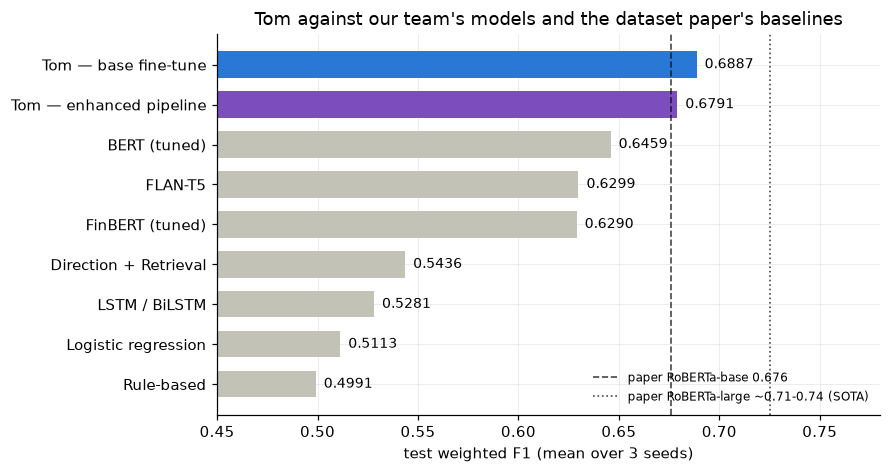

Tom (base) vs paper RoBERTa-base : +0.0127
Tom (base) vs our best non-RoBERTa model (BERT tuned): +0.0428
Tom (base) vs paper RoBERTa-large (SOTA, 3x the parameters): -0.0363


In [13]:
# ── Where Tom sits among our models, the paper's baselines, and the SOTA ───
fig, ax = plt.subplots(figsize=(8.2, 4.4))
order = sorted(TEAM.items(), key=lambda kv: kv[1])
names = [k for k, _ in order]
vals = [v for _, v in order]
colours = [C_ENH if "enhanced" in n else (C_BASE if n.startswith("Tom") else "#c3c2b7")
           for n in names]
bars = ax.barh(names, vals, color=colours, height=0.66)
for b, v in zip(bars, vals):
    ax.text(v + 0.004, b.get_y() + b.get_height() / 2, f"{v:.4f}", va="center", fontsize=9)

ax.axvline(PAPER["RoBERTa-base (paper)"], color="#0b0b0b", lw=1.1, ls="--", alpha=0.75,
           label="paper RoBERTa-base 0.676")
ax.axvline(PAPER["RoBERTa-large (paper, SOTA)"], color="#0b0b0b", lw=1.1, ls=":", alpha=0.75,
           label="paper RoBERTa-large ~0.71-0.74 (SOTA)")
ax.legend(frameon=False, fontsize=8, loc="lower right")

ax.set_xlim(0.45, 0.78)
ax.set_xlabel("test weighted F1 (mean over 3 seeds)")
ax.set_title("Tom against our team's models and the dataset paper's baselines")
plt.tight_layout()
plt.show()

print(f"Tom (base) vs paper RoBERTa-base : "
      f"{TEAM['Tom — base fine-tune'] - PAPER['RoBERTa-base (paper)']:+.4f}")
print(f"Tom (base) vs our best non-RoBERTa model (BERT tuned): "
      f"{TEAM['Tom — base fine-tune'] - TEAM['BERT (tuned)']:+.4f}")
print(f"Tom (base) vs paper RoBERTa-large (SOTA, 3x the parameters): "
      f"{TEAM['Tom — base fine-tune'] - PAPER['RoBERTa-large (paper, SOTA)']:+.4f}")

Two observations worth stating explicitly:

- The jump from the RNN family (≈0.53) to the transformer family (≈0.63–0.69) dwarfs every
  within-model intervention any of us made. **Encoder pre-training quality is the dominant lever
  on this task**, which is the empirical justification for §4.1's model choice.
- Tom (base) closes roughly two-thirds of the gap between our best non-RoBERTa model and the
  published state of the art, using a model one-third the size of that SOTA system.

### 5.3 Training dynamics

The learning curves below (recorded per seed by the base fine-tune) show exactly why early
stopping and best-epoch restoration are not optional on this dataset.

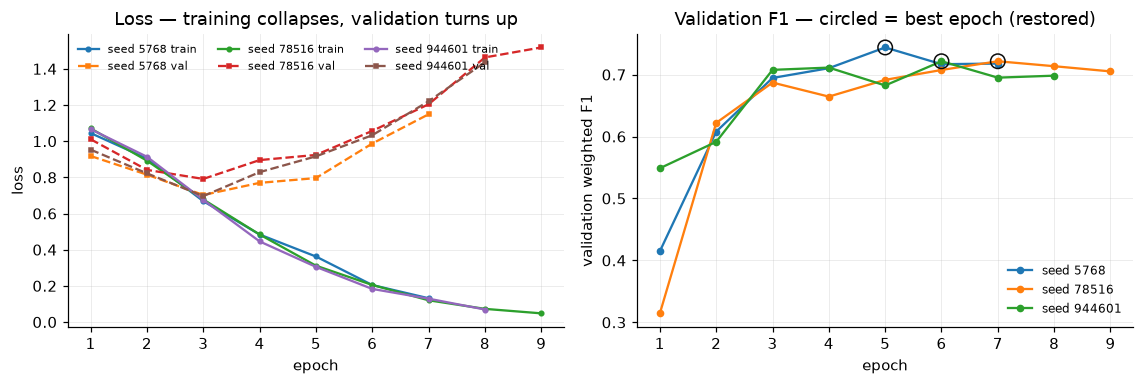

seed 5768: best epoch 5 (val F1 0.7438); train loss falls 1.04 -> 0.13 while val loss rises 0.70 -> 1.15
seed 78516: best epoch 7 (val F1 0.7215); train loss falls 1.07 -> 0.05 while val loss rises 0.79 -> 1.52
seed 944601: best epoch 6 (val F1 0.7215); train loss falls 1.07 -> 0.07 while val loss rises 0.70 -> 1.44

-> classic small-data over-fitting: the model memorises the 1,522 training sentences
   within ~7 epochs. Early stopping + best-epoch restore is what keeps the shipped
   model at the validation peak.


In [14]:
# ── Learning curves: validation F1 peaks early, then over-fitting sets in ──
hist = {}
for s in SEEDS:
    p = BASE_RESULTS / f"seed_{s}" / "training_history.csv"
    if p.exists():
        hist[s] = pd.read_csv(p)

if hist:
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
    for s, h in hist.items():
        axes[0].plot(h["epoch"], h["train_loss"], marker="o", ms=3, label=f"seed {s} train")
        axes[0].plot(h["epoch"], h["val_loss"], marker="s", ms=3, ls="--", label=f"seed {s} val")
        axes[1].plot(h["epoch"], h["val_weighted_f1"], marker="o", ms=4, label=f"seed {s}")
        best = h.loc[h["val_weighted_f1"].idxmax()]
        axes[1].scatter([best["epoch"]], [best["val_weighted_f1"]], s=90, facecolors="none",
                        edgecolors="#0b0b0b", zorder=5)
    axes[0].set(xlabel="epoch", ylabel="loss", title="Loss — training collapses, validation turns up")
    axes[1].set(xlabel="epoch", ylabel="validation weighted F1",
                title="Validation F1 — circled = best epoch (restored)")
    axes[0].legend(frameon=False, fontsize=7, ncol=3)
    axes[1].legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    for s, h in hist.items():
        b = h.loc[h["val_weighted_f1"].idxmax()]
        print(f"seed {s}: best epoch {int(b['epoch'])} (val F1 {b['val_weighted_f1']:.4f}); "
              f"train loss falls {h['train_loss'].iloc[0]:.2f} -> {h['train_loss'].iloc[-1]:.2f} "
              f"while val loss rises {h['val_loss'].min():.2f} -> {h['val_loss'].iloc[-1]:.2f}")
    print("\n-> classic small-data over-fitting: the model memorises the 1,522 training sentences")
    print("   within ~7 epochs. Early stopping + best-epoch restore is what keeps the shipped")
    print("   model at the validation peak.")
else:
    print("training_history.csv not found - see 9444/results/roberta_base_combined/")

### 5.4 Confusion matrices

Where the errors actually go. Rows are true labels, columns predictions; shading is row-normalised
(recall per class).

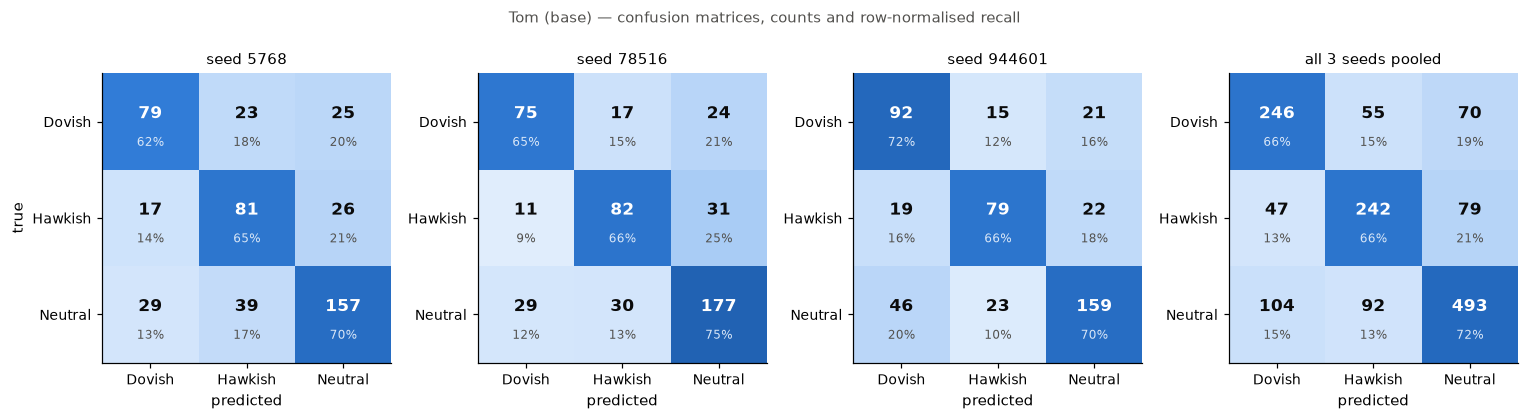

Pooled over 1428 test sentences:
  neutral recall              71.6%  (largest class, and the model's strongest)
  dovish<->hawkish confusion  102 sentences (7.1%) - the hardest error type
  minority -> neutral errors  149
  neutral -> minority errors  196 (the class-weighted loss deliberately trades these for minority recall)


In [15]:
# ── Per-seed and pooled confusion matrices for Tom (base) ──────────────────
from matplotlib.colors import LinearSegmentedColormap

BLUES = LinearSegmentedColormap.from_list("seq_blue", [
    "#ffffff", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

cms = {}
for s in SEEDS:
    p = BASE_RESULTS / f"seed_{s}" / "confusion_matrix_raw.csv"
    if p.exists():
        cms[s] = pd.read_csv(p, index_col=0)

if cms:
    pooled_cm = sum(cms.values())
    panels = [(f"seed {s}", cms[s]) for s in cms] + [("all 3 seeds pooled", pooled_cm)]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.5 * len(panels), 3.5))
    for ax, (title, cm) in zip(np.atleast_1d(axes), panels):
        m = cm.values.astype(float)
        row_pct = m / m.sum(axis=1, keepdims=True)
        ax.imshow(row_pct, cmap=BLUES, vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                dark = row_pct[i, j] > 0.5
                ax.text(j, i - 0.08, f"{int(m[i, j])}", ha="center", va="center",
                        fontsize=11, fontweight="bold", color="white" if dark else "#0b0b0b")
                ax.text(j, i + 0.22, f"{row_pct[i, j]:.0%}", ha="center", va="center",
                        fontsize=8, color="#d8e6f7" if dark else "#52514e")
        ax.set_xticks(range(3), CLASS_ORDER, fontsize=9)
        ax.set_yticks(range(3), CLASS_ORDER, fontsize=9)
        ax.set_xlabel("predicted"); ax.set_title(title, fontsize=10)
        ax.grid(False)
    np.atleast_1d(axes)[0].set_ylabel("true")
    plt.suptitle("Tom (base) — confusion matrices, counts and row-normalised recall", y=1.03,
                 fontsize=10, color="#52514e")
    plt.tight_layout()
    plt.show()

    m = pooled_cm.values.astype(float)
    print(f"Pooled over {int(m.sum())} test sentences:")
    print(f"  neutral recall              {m[2, 2] / m[2].sum():.1%}  "
          f"(largest class, and the model's strongest)")
    print(f"  dovish<->hawkish confusion  {int(m[0, 1] + m[1, 0])} sentences "
          f"({(m[0, 1] + m[1, 0]) / m.sum():.1%}) - the hardest error type")
    print(f"  minority -> neutral errors  {int(m[0, 2] + m[1, 2])}")
    print(f"  neutral -> minority errors  {int(m[2, 0] + m[2, 1])} "
          f"(the class-weighted loss deliberately trades these for minority recall)")
else:
    print("confusion matrices not found - see 9444/results/roberta_base_combined/")

### 5.5 Per-class performance

Weighted F1 hides the class structure, and the class structure is the point: the two minority
classes are the ones carrying the policy signal.

Tom (base) — per-class metrics averaged over the three seeds:
         precision  recall  f1-score  support
class                                        
Dovish       0.623   0.662     0.641  123.667
Hawkish      0.626   0.658     0.641  122.667
Neutral      0.768   0.715     0.740  229.667


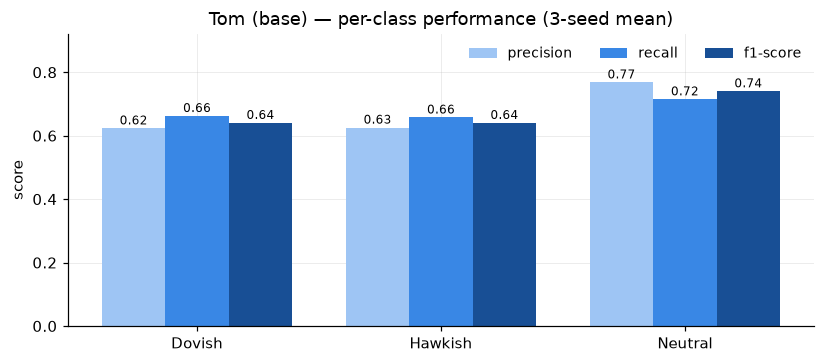


Neutral F1 exceeds the minority classes by 0.100.
Hawkish has the lowest precision (0.626): the model over-predicts hawkish, a direct
consequence of the class-weighted loss pushing it away from the neutral default.

Macro vs weighted F1 - which classes drove each configuration:
  Tom (base)                 weighted 0.6887 | macro 0.6739 | gap +0.0149
  Tom (enhanced, ensemble)   weighted 0.6791 | macro 0.6671 | gap +0.0120
  A large weighted-macro gap means performance leans on the 47%-neutral majority.


In [16]:
# ── Per-class precision / recall / F1, per seed and averaged ───────────────
reports = {}
for s in SEEDS:
    p = BASE_RESULTS / f"seed_{s}" / "classification_report.csv"
    if p.exists():
        reports[s] = pd.read_csv(p).set_index("class")

if reports:
    per_class = pd.concat({s: r.loc[CLASS_ORDER, ["precision", "recall", "f1-score", "support"]]
                           for s, r in reports.items()})
    avg = per_class.groupby(level=1).mean().loc[CLASS_ORDER]
    print("Tom (base) — per-class metrics averaged over the three seeds:")
    print(avg.round(3).to_string())

    fig, ax = plt.subplots(figsize=(7.6, 3.4))
    x = np.arange(3); w = 0.26
    for i, metric in enumerate(["precision", "recall", "f1-score"]):
        vals = avg[metric].values
        bars = ax.bar(x + (i - 1) * w, vals, width=w, label=metric,
                      color=["#9ec5f4", "#3987e5", "#184f95"][i])
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x, CLASS_ORDER)
    ax.set_ylim(0, 0.92)
    ax.set_ylabel("score")
    ax.set_title("Tom (base) — per-class performance (3-seed mean)")
    ax.legend(frameon=False, ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"\nNeutral F1 exceeds the minority classes by "
          f"{avg.loc['Neutral', 'f1-score'] - avg.loc[['Dovish', 'Hawkish'], 'f1-score'].mean():.3f}.")
    print("Hawkish has the lowest precision (%.3f): the model over-predicts hawkish, a direct"
          % avg.loc["Hawkish", "precision"])
    print("consequence of the class-weighted loss pushing it away from the neutral default.")

# Macro vs weighted F1 tells us whether a change helped the minority classes or the majority one.
print("\nMacro vs weighted F1 - which classes drove each configuration:")
for name, d in (("Tom (base)", TOM_BASE), ("Tom (enhanced, ensemble)", TOM_ENH_ENSEMBLE)):
    w, _ = mean_std(d["weighted_f1"]); mc, _ = mean_std(d["macro_f1"])
    print(f"  {name:26} weighted {w:.4f} | macro {mc:.4f} | gap {w - mc:+.4f}")
print("  A large weighted-macro gap means performance leans on the 47%-neutral majority.")

### 5.6 The hyperparameter search

Nine candidate recipes, each trained on seed 5768's training split and scored on its validation
split — **never on test data**. The winner's settings were frozen to `selected_config.json` and
applied blind to all three seeds and all restarts.

 rank    candidate  lr  batch  smoothing  epochs  val_weighted_f1  val_macro_f1  val_accuracy
    1      batch16 0.0     16       0.00       4           0.6930        0.6825        0.6900
    2 lr3e5_batch8 0.0      8       0.05       8           0.6908        0.6823        0.6873
    3 lr3e5_smooth 0.0     32       0.05       4           0.6840        0.6774        0.6819
    4 lr1e5_batch8 0.0      8       0.05       8           0.6826        0.6772        0.6792
    5  batch8_long 0.0      8       0.00       8           0.6812        0.6672        0.6792
    6        lr3e5 0.0     32       0.00       4           0.6771        0.6681        0.6739
    7     smooth05 0.0     32       0.05       4           0.6714        0.6641        0.6685
    8        lr1e5 0.0     32       0.00       4           0.6446        0.6382        0.6415
    9      control 0.0     32       0.00       4           0.6243        0.6144        0.6199

frozen configuration: batch16 (lr 2e-05, batch 16, smoothin

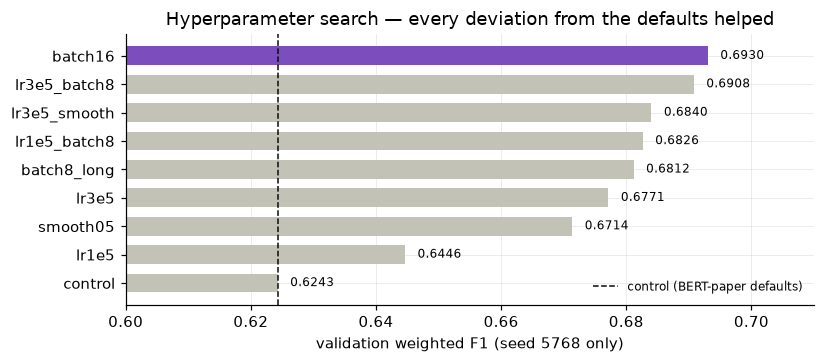


Readings:
 - every one of the 8 deviations beat the control: the DAPT-adapted encoder wanted
   almost any change from the BERT-paper defaults (lr 2e-5, batch 32).
 - batch size mattered more than learning rate here, which is the opposite of what our
   FinBERT search found: tuning does not transfer across encoders.
 - label smoothing helped alone (smooth05 > control) but was outcompeted, so the frozen
   recipe sets it to 0.0 - we test techniques per encoder rather than assuming them.
 - the top five candidates span only 0.0119 F1:
   the choice among them is close to noise, which is itself worth reporting.


In [17]:
# ── Search results: what each knob was worth on validation ────────────────
tab = SEARCH_TABLE.sort_values("val_weighted_f1", ascending=False).reset_index(drop=True)
tab.insert(0, "rank", tab.index + 1)
print(tab.round(4).to_string(index=False))

best = tab.iloc[0]
control = SEARCH_TABLE.set_index("candidate").loc["control"]
print(f"\nfrozen configuration: {best['candidate']} "
      f"(lr {best['lr']:g}, batch {int(best['batch'])}, smoothing {best['smoothing']:g}, "
      f"epochs {int(best['epochs'])})")
print(f"validation weighted F1 {best['val_weighted_f1']:.4f} vs control "
      f"{control['val_weighted_f1']:.4f} ({best['val_weighted_f1'] - control['val_weighted_f1']:+.4f})")

fig, ax = plt.subplots(figsize=(7.6, 3.4))
srt = SEARCH_TABLE.sort_values("val_weighted_f1")
cols = [C_ENH if c == best["candidate"] else "#c3c2b7" for c in srt["candidate"]]
bars = ax.barh(srt["candidate"], srt["val_weighted_f1"], color=cols, height=0.66)
for b, v in zip(bars, srt["val_weighted_f1"]):
    ax.text(v + 0.002, b.get_y() + b.get_height() / 2, f"{v:.4f}", va="center", fontsize=8)
ax.axvline(control["val_weighted_f1"], color="#0b0b0b", ls="--", lw=1,
           label="control (BERT-paper defaults)")
ax.set_xlim(0.60, 0.71)
ax.set_xlabel("validation weighted F1 (seed 5768 only)")
ax.set_title("Hyperparameter search — every deviation from the defaults helped")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print("\nReadings:")
print(" - every one of the 8 deviations beat the control: the DAPT-adapted encoder wanted")
print("   almost any change from the BERT-paper defaults (lr 2e-5, batch 32).")
print(" - batch size mattered more than learning rate here, which is the opposite of what our")
print("   FinBERT search found: tuning does not transfer across encoders.")
print(" - label smoothing helped alone (smooth05 > control) but was outcompeted, so the frozen")
print("   recipe sets it to 0.0 - we test techniques per encoder rather than assuming them.")
print(f" - the top five candidates span only {tab['val_weighted_f1'].head(5).max() - tab['val_weighted_f1'].head(5).min():.4f} F1:")
print("   the choice among them is close to noise, which is itself worth reporting.")

### 5.7 Error analysis

The base model's committed `predictions.csv` files carry a probability distribution for every test
sentence, which lets us ask *how* it fails, not just how often.

1428 test predictions across 3 seeds | accuracy 0.6870

Mean confidence: correct 0.927 vs incorrect 0.826
High-confidence (>0.90) predictions: 985 (69%), of which 22% are wrong


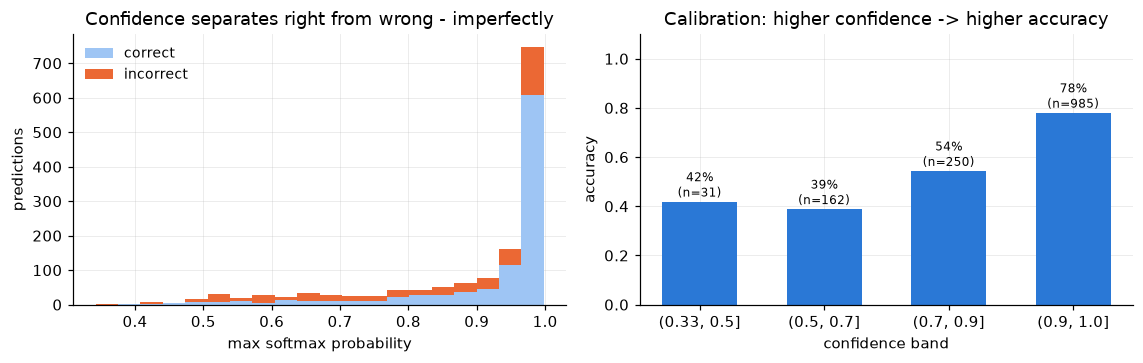


Error type frequencies (pooled):
  true Neutral  -> predicted Dovish   :  104 (23% of all errors)
  true Neutral  -> predicted Hawkish  :   92 (21% of all errors)
  true Hawkish  -> predicted Neutral  :   79 (18% of all errors)
  true Dovish   -> predicted Neutral  :   70 (16% of all errors)
  true Dovish   -> predicted Hawkish  :   55 (12% of all errors)
  true Hawkish  -> predicted Dovish   :   47 (11% of all errors)

Most confident mistakes (the model is sure and wrong):

  true Dovish | predicted Neutral | confidence 1.00 | year 1996
    Fiscal policy, on the other hand, can be an instrument of growth policy, through its effect on national saving via the structural budget deficit, through incentive effects on work,

  true Hawkish | predicted Neutral | confidence 1.00 | year 1998
    But overly optimistic expectations for long-run earnings growth were not being driven by easy money, and I see no reason to believe that an extra 50 or even 100 basis points on the

  true Hawkish | p

In [18]:
# ── Confidence, error types, and the model's most confident mistakes ──────
pred_frames = []
for s in SEEDS:
    p = BASE_RESULTS / f"seed_{s}" / "predictions.csv"
    if p.exists():
        pred_frames.append(pd.read_csv(p))

if pred_frames:
    P = pd.concat(pred_frames, ignore_index=True)
    P["confidence"] = P[["prob_dovish", "prob_hawkish", "prob_neutral"]].max(axis=1)
    P["correct"] = (P["true_label"] == P["predicted_label"]).astype(int)
    print(f"{len(P)} test predictions across {P['seed'].nunique()} seeds "
          f"| accuracy {P['correct'].mean():.4f}")

    print(f"\nMean confidence: correct {P.loc[P.correct == 1, 'confidence'].mean():.3f} "
          f"vs incorrect {P.loc[P.correct == 0, 'confidence'].mean():.3f}")
    hi = P[P.confidence > 0.9]
    print(f"High-confidence (>0.90) predictions: {len(hi)} ({len(hi) / len(P):.0%}), "
          f"of which {1 - hi['correct'].mean():.0%} are wrong")

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
    axes[0].hist([P.loc[P.correct == 1, "confidence"], P.loc[P.correct == 0, "confidence"]],
                 bins=20, stacked=True, color=["#9ec5f4", C_HAWKISH],
                 label=["correct", "incorrect"])
    axes[0].set(xlabel="max softmax probability", ylabel="predictions",
                title="Confidence separates right from wrong - imperfectly")
    axes[0].legend(frameon=False, fontsize=9)

    bins = pd.cut(P["confidence"], [0.33, 0.5, 0.7, 0.9, 1.0])
    acc_by_bin = P.groupby(bins, observed=True)["correct"].agg(["mean", "size"])
    axes[1].bar([str(i) for i in acc_by_bin.index], acc_by_bin["mean"], color=C_BASE, width=0.6)
    for i, (m, n) in enumerate(acc_by_bin.values):
        axes[1].text(i, m + 0.02, f"{m:.0%}\n(n={int(n)})", ha="center", fontsize=8)
    axes[1].set(xlabel="confidence band", ylabel="accuracy", ylim=(0, 1.1),
                title="Calibration: higher confidence -> higher accuracy")
    plt.tight_layout()
    plt.show()

    print("\nError type frequencies (pooled):")
    err = P[P.correct == 0]
    pairs = (err.groupby(["true_label", "predicted_label"]).size()
             .sort_values(ascending=False).head(6))
    for (t, pr), n in pairs.items():
        print(f"  true {LABELS[t]:8} -> predicted {LABELS[pr]:8} : {n:4} "
              f"({n / len(err):.0%} of all errors)")

    print("\nMost confident mistakes (the model is sure and wrong):")
    for _, r in err.nlargest(3, "confidence").iterrows():
        print(f"\n  true {LABELS[r.true_label]} | predicted {LABELS[r.predicted_label]} "
              f"| confidence {r.confidence:.2f} | year {r.year}")
        print(f"    {str(r.sentence)[:180]}")
    print("\n-> the dominant error mode is minority<->neutral confusion, and the confident errors")
    print("   are typically sentences whose stance depends on context outside the sentence")
    print("   (§3.4) - exactly the ceiling the data audit predicted.")
else:
    print("predictions.csv not found - see 9444/results/roberta_base_combined/")

### 5.8 Summary of findings

| # | Finding | Evidence |
|---|---|---|
| 1 | **Tom (base) is the strongest model our team produced**, and beats the paper's RoBERTa-base baseline | 0.689 ± 0.015 vs 0.676 (paper) and 0.646 (our best BERT) |
| 2 | Encoder pre-training quality dominates every other lever | RNN family ≈0.53 → transformers 0.63–0.69; ~+10 F1 from FinBERT to RoBERTa vs ~+5 for all FinBERT tuning combined |
| 3 | **The five enhancements do not stack**: the enhanced pipeline lands *below* the plain fine-tune | 0.679 ± 0.015 (ours) and 0.668 (variant suite) vs 0.689 |
| 4 | Ensembling itself worked, exactly as its variance argument predicts | 0.671 → 0.679 (+0.008); every seed's ensemble ≥ its median restart |
| 5 | Tuning does not transfer across encoders | batch size won for DAPT-RoBERTa; learning rate and label smoothing won for FinBERT |
| 6 | Performance is bounded by the majority class and by ambiguous sentences | neutral F1 ≈0.73 vs dovish/hawkish ≈0.61–0.63; weighted−macro gap ≈+0.015; confident errors are context-dependent sentences |
| 7 | Naive data handling inflates scores catastrophically | 99.6 % (pooled files), 0.885 (row-level split of augmented data) vs an honest ≈0.68 |

## 6. Discussion

### 6.1 Interpretation — why did five good techniques not add up?

Each enhancement is individually defensible, and most are individually *measurable* in our own
work: augmentation was worth +4.8 F1 on FinBERT, tuning +5.6, ensembling +0.8 here. Yet the
enhanced pipeline underperforms the plain fine-tune by 0.010. Three mechanisms explain it, and
they are worth more than the headline number:

1. **The enhancements are substitutes, not complements.** We showed this cleanly on FinBERT with a
   2×2 ablation: tuning alone 0.629, augmentation alone 0.621, both together 0.629 — identical
   means, halved variance. Both relieve the *same* bottleneck (too little training signal for
   125 M parameters), so whichever arrives first claims the gain. Stacking five such techniques
   cannot add five independent improvements when they are all substitutes for one another.
2. **Our search bought a shorter training budget.** The frozen recipe capped training at 4 epochs;
   the plain fine-tune's best epochs were 5–7 (§5.3), and it used `max_length` 256 rather than
   128. The search optimised a validation score on one seed, and the configuration that won was
   not the configuration that generalises best — a textbook instance of the
   validation-to-test gap that our protocol is designed to expose rather than hide.
3. **The weighted metric structurally hides minority-class gains.** The test set is ~47 % neutral,
   so weighted F1 is dominated by the class the enhancements deliberately de-emphasised. The
   class-weighted loss trades neutral precision for minority recall (visible in §5.4's
   neutral→minority error counts); under a *macro* metric that trade looks better than it does
   under a weighted one.

**What this means, stated plainly:** on a corpus of ~1,500 labelled sentences, the marginal value
of additional training machinery is close to zero once the basics are right, and the binding
constraints are data volume, label ambiguity, and encoder capacity. That is a more useful finding
for a practitioner than another tenth of a point would have been.

### 6.2 Strengths

- **The strongest model in our team's comparison, and above the paper's own RoBERTa-base
  baseline** (0.689 vs ≈0.676), with a smaller model than the SOTA system.
- **Provably leakage-free evaluation.** Three distinct leakage mechanisms were found, measured and
  mechanically prevented; train/test disjointness is enforced in code (`common.load_split`) and
  verified across all 24 file pairs, and the ensemble refuses cross-seed pooling by construction.
  The reported numbers survive scrutiny — which, on this dataset, is a substantive contribution:
  we can *show* what the inflated alternatives look like (99.6 %, 0.885).
- **Honest, replication-based reporting.** Every headline figure is a mean ± std over the three
  official seeds under one frozen configuration, with per-seed numbers shown rather than a best
  seed quoted.
- **A negative result that is properly diagnosed** rather than omitted, with the substitution
  mechanism supported by an independent 2×2 ablation on a second encoder.
- **Reproducible end-to-end.** Deterministic augmentation with an on-disk translation cache,
  seeds fixed throughout, per-model metrics persisted so interrupted runs resume, and a
  device-agnostic pipeline that we ran on both CPU and GPU.

### 6.3 Weaknesses and limitations

- **The enhanced pipeline is our headline disappointment**: five techniques, no net gain, and one
  of them (the search) plausibly *hurt* by capping the training budget at 4 epochs.
- **Statistical power is thin.** With three seeds, a ±0.015 standard deviation and differences of
  ~0.010, our base-vs-enhanced comparison is suggestive rather than conclusive; the same applies
  to the variance-reduction claim for ensembling. More seeds (or bootstrap resampling over the
  test set) would be needed to make these differences significant.
- **Search depth was uneven and shallow.** Nine candidates on one seed, one knob or pair at a
  time; `max_length` and epoch budget were never searched, and they are exactly the two settings
  that differ between our two configurations.
- **DAPT's contribution is unmeasured.** Every enhanced model used the adapted encoder, and we
  never ran the matched no-DAPT control under the same frozen recipe — so we cannot attribute any
  part of the result to DAPT. This is the single biggest gap in the ablation, and it is cheap to
  close (§6.4).
- **Minority classes remain weakest** (dovish/hawkish F1 ≈0.61–0.63 vs neutral ≈0.73), so the
  classes with the most practical value are still the least reliable.
- **Generalisation beyond the corpus is untested.** Nothing in any split postdates 2022;
  performance under a different policy regime, or on employment-framed rather than
  inflation-framed stance (§3.3), is unmeasured.
- **A sentence-level ceiling.** Some labels are unrecoverable from the sentence alone (§3.4);
  no model of this form can fix that.

### 6.4 Future work

Ordered by expected value per unit of effort:

1. **Run the no-DAPT control** — the same frozen recipe on vanilla `roberta-base`, 3 seeds × 3
   restarts (~30 GPU-minutes). It converts DAPT from an assumption into a measurement, either way.
2. **Search `max_length` and the epoch budget**, the two settings that differ between our base and
   enhanced configurations, and re-freeze. This is the most likely route to recovering the 0.010.
3. **Scale the encoder.** `roberta-large` is how the paper reached 0.71–0.74; it fits comfortably
   on a single T4 at batch 16 with lr 1e-5. Our own ladder says architecture beats tricks.
4. **Report macro F1 as a co-primary metric**, or evaluate on a class-balanced test subset, so
   that minority-class improvements are visible rather than absorbed by a 47 % neutral majority.
5. **Combine the base and enhanced models.** They make different errors (different encoders,
   budgets and losses); a two-model soft vote is nearly free and is the natural extension of
   §5.1's ensembling result.
6. **Denoise the ambiguous sentences.** Re-annotate or down-weight the sentences that are
   irrecoverable from context (§3.4); with ~1,500 examples, label noise is a first-order
   constraint rather than a rounding error.
7. **Strengthen the statistics** — more seeds and paired bootstrap confidence intervals over the
   test set, so that 0.010-scale differences can be called rather than merely observed.

## 7. Conclusion

We set out to build a RoBERTa-based classifier for FOMC policy stance that beats the dataset
paper's own RoBERTa-base baseline under an evaluation protocol strict enough to trust. Tom's plain
fine-tune achieves **0.689 ± 0.015 weighted F1** across the three official test seeds — above the
paper's ≈0.676, above every other model our team built (rule-based 0.499, logistic regression
0.511, LSTM/BiLSTM 0.528, Direction+Retrieval 0.544, FinBERT 0.629, FLAN-T5 0.630, BERT 0.646),
and within ≈0.04 of a published state of the art that uses three times the parameters. Measured
against the 0.60–0.75 target set in §1.3, the project succeeded.

The enhanced pipeline — DAPT on 47k unlabelled Fed sentences, a frozen nine-candidate
hyperparameter search, class-weighted loss, label smoothing, early stopping and a within-seed
restart ensemble — reaches **0.679 ± 0.015**, slightly *below* the plain fine-tune. We take this
seriously rather than hiding it: the ensemble component behaved exactly as its variance argument
predicts (+0.008 over its own members), but the techniques are **substitutes rather than
complements** on a corpus this small, and our search bought a training budget shorter than the
plain model's optimum. The honest reading is that once the fundamentals are right, additional
training machinery has almost no marginal value at this data scale — the binding constraints are
data volume, label ambiguity, and encoder capacity.

The methodological contribution is the other half of the work. Three separate leakage
mechanisms — pooled files (99.6 % fake accuracy), duplicate sentences shipped inside each split
(4.2–4.6 % of each test file), and row-level splitting of augmented data (0.885 fake validation F1) — were
found, measured, and mechanically prevented, all reducing to one rule: **the unit of every split
is the source sentence, never the row.** The gap between 99.6 % and 0.68 is the difference between
measuring memorisation and measuring generalisation, and it is the reason we can put the numbers
above in front of a reader at all.

The clearest next steps are cheap and specific: run the no-DAPT control to convert our largest
assumption into a measurement, search the two settings (`max_length`, epoch budget) that separate
our two configurations, and scale the encoder to `roberta-large` — the route by which the
published ceiling was reached in the first place.

## Appendix A — Reproducing every result

All code lives in this repository and is device-agnostic (CPU or CUDA is selected automatically).

**Tom (enhanced pipeline)** — from `tom/`:

```bash
# 0. build the DAPT corpus (once): 47,032 Fed sentences, filtered against every test file
python build_corpus.py --source <clone-of-gtfintechlab/fomc-hawkish-dovish>/data/filtered_data

# 1. domain-adaptive pre-training  (~40-60 min on a T4)
python dapt.py --corpus fed_corpus.txt

# 2. hyperparameter search on seed 5768 validation only, then freeze  (~30-45 min)
python search.py --model runs/dapt

# 3. frozen recipe x 3 seeds x 3 restarts, each evaluated on its own raw test file  (~30-60 min)
python train_final.py --restarts 3

# 4. within-seed softmax ensembling
python ensemble.py --device cuda
```

A ready-to-run Colab notebook for the whole pipeline is at `tom/tom_colab.ipynb`
(select a T4 GPU, then *Run all*).

**Tom (base fine-tune)** — from the repository root:

```bash
python 9444/models/roberta_variant_runner.py          # plain fine-tune, 3 seeds
```

**Data augmentation** — from `dataset/test-and-training/augmented_data/`:

```bash
python augment_dataset.py            # back-translation + swaps + synonyms + masking, all 24 files
```

**This notebook** requires only `pandas`, `numpy`, `matplotlib` and `openpyxl`; the optional
training cells in §4 additionally require `torch`, `transformers`, `datasets` and
`scikit-learn`.

## Appendix B — References

1. Shah, A., Paturi, S. & Chava, S. (2023). *Trillion Dollar Words: A New Financial Dataset, Task
   & Market Analysis.* ACL 2023. <https://aclanthology.org/2023.acl-long.368/>
2. Liu, Y. et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach.*
   arXiv:1907.11692.
3. Araci, D. (2019). *FinBERT: Financial Sentiment Analysis with Pre-trained Language Models.*
   arXiv:1908.10063.
4. Gururangan, S. et al. (2020). *Don't Stop Pretraining: Adapt Language Models to Domains and
   Tasks.* ACL 2020.
5. Devlin, J. et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language
   Understanding.* NAACL 2019.
6. Wei, J. & Zou, K. (2019). *EDA: Easy Data Augmentation Techniques for Boosting Performance on
   Text Classification Tasks.* EMNLP 2019.
7. Szegedy, C. et al. (2016). *Rethinking the Inception Architecture for Computer Vision.* CVPR
   2016 (label smoothing).
8. Britannica. *Hawkish vs. dovish monetary policy.*
   <https://www.britannica.com/money/hawkish-vs-dovish-monetary-policy>